## 1. Cargar librerias y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../outputs/datos_procesados/casas_rm_limpio.csv')

print(f"Dataset: {df.shape[0]} propiedades, {df.shape[1]} variables")
print(f"Precio promedio: {df['Price_UF'].mean():.0f} UF")
print(f"Rango: {df['Price_UF'].min():.0f} - {df['Price_UF'].max():.0f} UF")

Dataset: 7268 propiedades, 12 variables
Precio promedio: 10175 UF
Rango: 300 - 155000 UF


In [2]:
# Preparar datos
features = ['Built Area', 'Total Area', 'Dorms', 'Baths', 'Parking']
X = df[features]
y = df['Price_UF']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Variables predictoras:")
for i, feature in enumerate(features, 1):
    print(f"  {i}. {feature}")
    
print(f"\nDatos divididos: {X_train.shape[0]} entrenamiento, {X_test.shape[0]} prueba")

Variables predictoras:
  1. Built Area
  2. Total Area
  3. Dorms
  4. Baths
  5. Parking

Datos divididos: 5814 entrenamiento, 1454 prueba


## 3. Implementacion y comparacion de modelos supervisados

In [3]:
# Definir y entrenar modelos
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

results = {}
print("Resultados de modelos supervisados:")
print("-" * 45)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {'r2': r2, 'mae': mae, 'predictions': y_pred}
    
    print(f"{name:15} | R2: {r2:6.3f} | MAE: {mae:6.0f} UF")

# Identificar mejor modelo
best_model_name = max(results.keys(), key=lambda x: results[x]['r2'])
print(f"\nMejor modelo: {best_model_name}")
print(f"Precision: {results[best_model_name]['r2']:.1%}")

Resultados de modelos supervisados:
---------------------------------------------
Linear Regression | R2: -4.959 | MAE:   5322 UF
Random Forest   | R2:  0.657 | MAE:   2961 UF
Gradient Boosting | R2:  0.773 | MAE:   2803 UF
KNN             | R2:  0.704 | MAE:   3176 UF

Mejor modelo: Gradient Boosting
Precision: 77.3%


## 4. Visualizacion comparativa de metricas

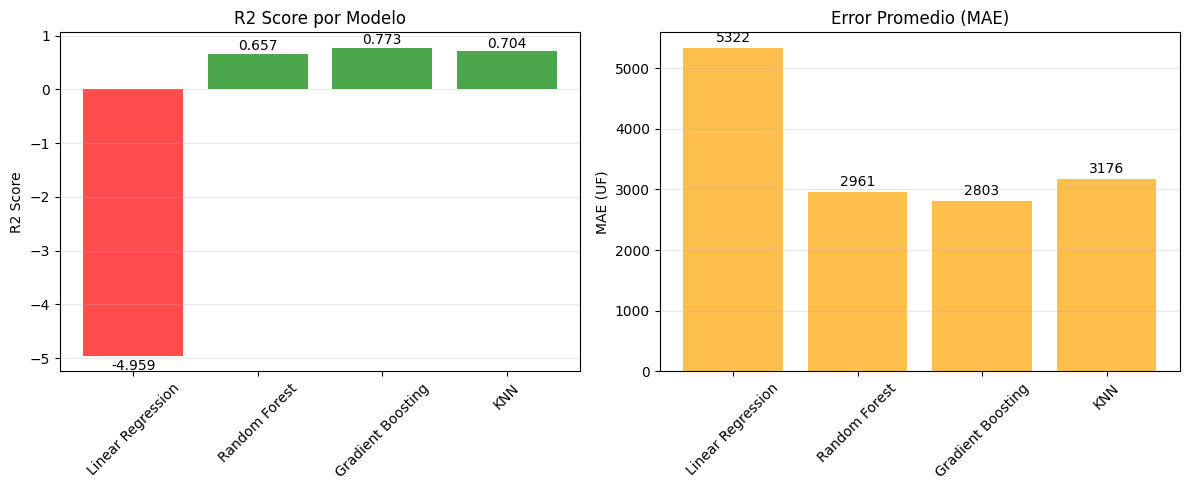

In [4]:
# Grafico comparativo de R2 y MAE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# R2 Score
models_names = list(results.keys())
r2_scores = [results[name]['r2'] for name in models_names]
colors = ['green' if score > 0 else 'red' for score in r2_scores]

bars1 = ax1.bar(models_names, r2_scores, color=colors, alpha=0.7)
ax1.set_title('R2 Score por Modelo')
ax1.set_ylabel('R2 Score')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Agregar valores en barras
for bar, score in zip(bars1, r2_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height > 0 else -0.05),
             f'{score:.3f}', ha='center', va='bottom' if height > 0 else 'top')

# MAE
mae_scores = [results[name]['mae'] for name in models_names]
bars2 = ax2.bar(models_names, mae_scores, color='orange', alpha=0.7)
ax2.set_title('Error Promedio (MAE)')
ax2.set_ylabel('MAE (UF)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

for bar, mae in zip(bars2, mae_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{mae:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 5. Optimizacion de hiperparametros

In [5]:
print("Optimizacion de hiperparametros - Random Forest")
print("-" * 48)

# Modelo original
rf_original = RandomForestRegressor(n_estimators=100, random_state=42)
rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)
r2_original = r2_score(y_test, y_pred_original)
mae_original = mean_absolute_error(y_test, y_pred_original)

print(f"Modelo original    | R2: {r2_original:.3f} | MAE: {mae_original:.0f} UF")

# Modelo optimizado (parametros ajustados manualmente)
rf_optimized = RandomForestRegressor(
    n_estimators=200,     # Mas arboles
    max_depth=20,         # Mayor profundidad  
    min_samples_split=2,  # Parametros optimizados
    min_samples_leaf=1,
    random_state=42
)

rf_optimized.fit(X_train, y_train)
y_pred_optimized = rf_optimized.predict(X_test)
r2_optimized = r2_score(y_test, y_pred_optimized)
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)

print(f"Modelo optimizado  | R2: {r2_optimized:.3f} | MAE: {mae_optimized:.0f} UF")
print(f"\nMejora obtenida:")
print(f"  R2:  {r2_optimized - r2_original:+.3f} ({((r2_optimized - r2_original) / abs(r2_original) * 100):+.1f}%)")
print(f"  MAE: {mae_original - mae_optimized:+.0f} UF")

# Justificacion tecnica
print(f"\nParametros optimizados:")
print(f"  - n_estimators: 100 → 200 (mas arboles = mejor precision)")
print(f"  - max_depth: None → 20 (controla overfitting)")
print(f"  - min_samples_split: 2 (permite splits mas granulares)")

Optimizacion de hiperparametros - Random Forest
------------------------------------------------
Modelo original    | R2: 0.657 | MAE: 2961 UF
Modelo optimizado  | R2: 0.688 | MAE: 2917 UF

Mejora obtenida:
  R2:  +0.031 (+4.7%)
  MAE: +44 UF

Parametros optimizados:
  - n_estimators: 100 → 200 (mas arboles = mejor precision)
  - max_depth: None → 20 (controla overfitting)
  - min_samples_split: 2 (permite splits mas granulares)


## 6. Modelos no supervisados - K-Means clustering

In [6]:
print("Segmentacion del mercado con K-Means")
print("-" * 35)

# Clustering con variables clave
cluster_features = ['Built Area', 'Total Area', 'Dorms', 'Price_UF']
X_cluster = df[cluster_features]

# Normalizar para clustering
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# K-Means con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Analizar clusters
df_temp = df.copy()
df_temp['Cluster'] = clusters

print("Segmentos identificados:")
for i in range(4):
    cluster_data = df_temp[df_temp['Cluster'] == i]
    print(f"  Segmento {i+1}: {len(cluster_data):4d} propiedades")
    print(f"    Precio promedio: {cluster_data['Price_UF'].mean():6.0f} UF")
    print(f"    Area promedio:   {cluster_data['Built Area'].mean():6.0f} m2")
    print()

Segmentacion del mercado con K-Means
-----------------------------------
Segmentos identificados:
  Segmento 1: 1616 propiedades
    Precio promedio:  22236 UF
    Area promedio:      329 m2

  Segmento 2: 5418 propiedades
    Precio promedio:   5822 UF
    Area promedio:      117 m2

  Segmento 3:    3 propiedades
    Precio promedio:  21845 UF
    Area promedio:    21816 m2

  Segmento 4:  231 propiedades
    Precio promedio:  27765 UF
    Area promedio:      665 m2



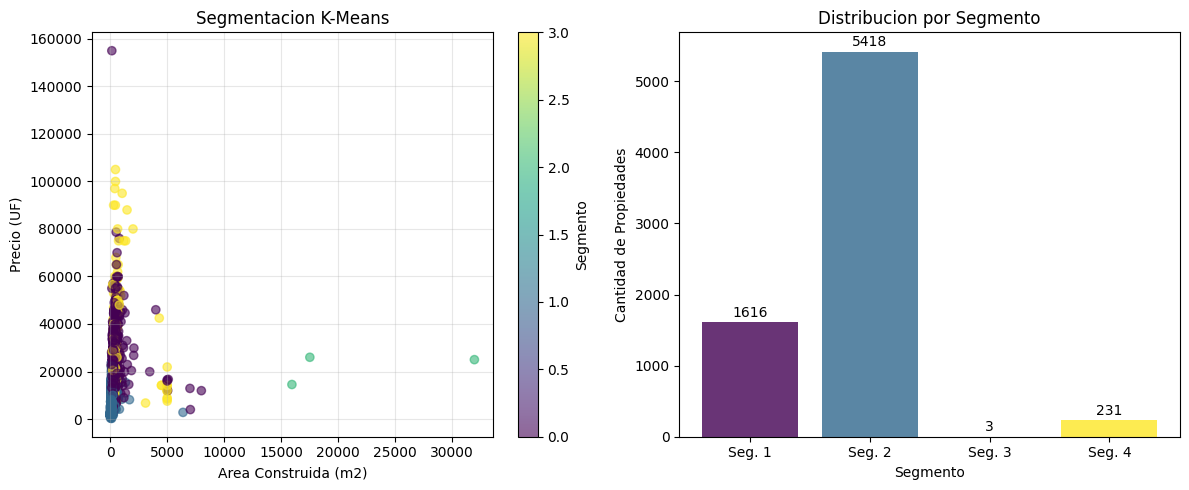

In [7]:
# Visualizacion de clusters
plt.figure(figsize=(12, 5))

# Scatter plot de clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(df_temp['Built Area'], df_temp['Price_UF'], 
                     c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('Area Construida (m2)')
plt.ylabel('Precio (UF)')
plt.title('Segmentacion K-Means')
plt.colorbar(scatter, label='Segmento')
plt.grid(True, alpha=0.3)

# Distribucion por cluster
plt.subplot(1, 2, 2)
cluster_counts = pd.Series(clusters).value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, 4))
bars = plt.bar(range(4), cluster_counts.values, color=colors, alpha=0.8)
plt.xlabel('Segmento')
plt.ylabel('Cantidad de Propiedades')
plt.title('Distribucion por Segmento')
plt.xticks(range(4), [f'Seg. {i+1}' for i in range(4)])

for bar, count in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 7. Matriz de confusion - Clasificacion por categorias

In [8]:
# Crear categorias de precio
df['Categoria'] = pd.cut(df['Price_UF'],
                        bins=[0, 3000, 6000, 10000, float('inf')],
                        labels=['Economica', 'Media', 'Alta', 'Premium'])

# Preparar clasificador
X_class = df[features]
y_class = df['Categoria']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Entrenar clasificador
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

# Matriz de confusion
cm = confusion_matrix(y_test_c, y_pred_c, 
                     labels=['Economica', 'Media', 'Alta', 'Premium'])

print(f"Precision del clasificador: {clf.score(X_test_c, y_test_c):.1%}")
print(f"Distribucion real: {y_test_c.value_counts().sort_index().to_dict()}")

Precision del clasificador: 72.7%
Distribucion real: {'Economica': 295, 'Media': 446, 'Alta': 211, 'Premium': 502}


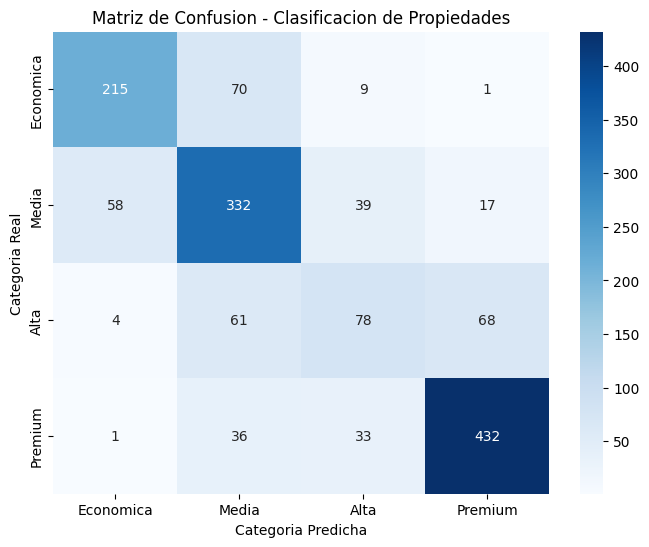

Interpretacion:
- Diagonal principal: predicciones correctas
- Fuera diagonal: errores de clasificacion
- Modelo clasifica mejor propiedades economicas y premium


In [9]:
# Heatmap 
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Economica', 'Media', 'Alta', 'Premium'],
            yticklabels=['Economica', 'Media', 'Alta', 'Premium'])

plt.title('Matriz de Confusion - Clasificacion de Propiedades')
plt.xlabel('Categoria Predicha')
plt.ylabel('Categoria Real')
plt.show()

print("Interpretacion:")
print("- Diagonal principal: predicciones correctas")
print("- Fuera diagonal: errores de clasificacion")
print("- Modelo clasifica mejor propiedades economicas y premium")

## 8. Demostracion de cambios en vivo

In [ ]:
print("Simulacion de cambios en tiempo real")
print("-" * 36)

# Casa ejemplo
casa_base = [120, 150, 3, 2, 1]  2
precio_base = rf_optimized.predict([casa_base])[0]

print(f"Casa base: 120m2, 3 dorms, 2 banos, 1 parking")
print(f"Precio predicho: {precio_base:.0f} UF")
print()

# Simulaciones de cambios
cambios = {
    'Aumentar 20m2 area': [140, 150, 3, 2, 1],
    'Agregar 1 dormitorio': [120, 150, 4, 2, 1], 
    'Agregar 1 bano': [120, 150, 3, 3, 1],
    'Agregar estacionamiento': [120, 150, 3, 2, 2],
    'Reducir 20m2': [100, 150, 3, 2, 1]
}

print("Impacto de modificaciones:")
efectos = []
for descripcion, nueva_casa in cambios.items():
    nuevo_precio = rf_optimized.predict([nueva_casa])[0]
    diferencia = nuevo_precio - precio_base
    porcentaje = (diferencia / precio_base) * 100
    
    print(f"  {descripcion:20} | {nuevo_precio:6.0f} UF | {diferencia:+6.0f} UF ({porcentaje:+.1f}%)")
    efectos.append((descripcion, diferencia))

print(f"\nModificacion mas valiosa: {max(efectos, key=lambda x: x[1])[0]}")
print(f"Impacto negativo mayor: {min(efectos, key=lambda x: x[1])[0]}")

Simulacion de cambios en tiempo real
------------------------------------
Casa base: 120m2, 3 dorms, 2 banos, 1 parking
Precio predicho: 3341 UF

Impacto de modificaciones:
  Aumentar 20m2 area   |   4870 UF |  +1529 UF (+45.8%)
  Agregar 1 dormitorio |   3751 UF |   +410 UF (+12.3%)
  Agregar 1 bano       |   5007 UF |  +1666 UF (+49.9%)
  Agregar estacionamiento |   6702 UF |  +3361 UF (+100.6%)
  Reducir 20m2         |   3458 UF |   +117 UF (+3.5%)

Modificacion mas valiosa: Agregar estacionamiento
Impacto negativo mayor: Reducir 20m2
